## Packages

In [1]:
import numpy as np
from scipy.optimize import minimize
from numpy.linalg import cholesky, solve, det
import matplotlib.pyplot as plt

## Classes

### Means and kernels

In [2]:
class ConstantMean:
    def __init__(self, constant=0.0):
        self.constant = constant

    def __call__(self, X):
        """Compute the constant mean vector."""
        return np.full((X.shape[0], 1), self.constant)

class SineMean:
    def __init__(self, amplitude=1.0, frequency=1.0, phase=0.0):
        self.amplitude = amplitude
        self.frequency = frequency
        self.phase = phase

    def __call__(self, X):
        """
        Compute the sine mean vector.
        Applies sine to the first dimension of X.
        """
        return self.amplitude * np.sin(self.frequency * X[:, [0]] + self.phase)

class RBFKernel:
    def __init__(self, lengthscale=1.0, variance=1.0):
        self.lengthscale = lengthscale
        self.variance = variance

    def __call__(self, X1, X2):
        """Compute the RBF kernel matrix."""
        sqdist = np.sum(X1**2, 1).reshape(-1, 1) + np.sum(X2**2, 1) - 2 * np.dot(X1, X2.T)
        return self.variance * np.exp(-0.5 / self.lengthscale**2 * sqdist)

### Weighting functions

In [3]:
class InverseMultiquadraticKernel:
    def __init__(self, beta=1.0, c=1.0):
        self.beta = beta
        self.c = c

    def __call__(self, x, y):
        x = np.atleast_2d(x)
        y = np.atleast_2d(y)

        return self.beta * (1 + ((y-x)**2)/(self.c**2))**-0.5

    def gradient_log_squared(self, x, y):
        x = np.atleast_2d(x)
        y = np.atleast_2d(y)

        return 2 * (x - y)/(self.c**2) * (1+(y-x)**2/(self.c**2))**-1

## Single-output GPs

### Standard GP

In [4]:
class GaussianProcessRegressor:
    def __init__(self, mean, kernel, noise=1e-5):
        self.mean = mean
        self.kernel = kernel
        self.noise = noise
        self.is_fitted = False

    def fit(self, X_train, y_train):
        self.X_train = X_train
        self.y_train = y_train.reshape(-1, 1)
        self.n = len(X_train)

        self.m = self.mean(X_train)
        self.K = self.kernel(X_train, X_train)

        self.K_noise = self.K + self.noise * np.eye(len(self.X_train))
        self.K_noise_inv = np.linalg.inv(self.K + self.noise * np.eye(len(self.X_train)))

        self.is_fitted = True

    def predict(self, X_test):
        if not self.is_fitted:
            raise RuntimeError("Model not fitted yet.")

        K_star = self.kernel(self.X_train, X_test)
        K_ss = self.kernel(X_test, X_test)

        mu = self.mean(X_test) + K_star.T @ self.K_noise_inv @ (self.y_train - self.m)
        cov = K_ss - K_star.T @ self.K_noise_inv @ K_star

        return mu, cov

    def negative_mll(self, params):
        lengthscale, variance, noise = np.exp(params)
        kernel = RBFKernel(lengthscale, variance)
        K = kernel(self.X_train, self.X_train)
        K_noise = K + noise * np.eye(len(self.X_train))
        m = self.mean(self.X_train)

        try:
            K_inv = np.linalg.inv(K_noise)
            diff = self.y_train - m
            log_det = np.linalg.slogdet(K_noise)[1]  # More stable than np.log(det)

            mll = -0.5 * diff.T @ K_inv @ diff - 0.5 * log_det - 0.5 * self.n * np.log(2 * np.pi)
            mll = mll.item()

            print(f"[INFO] lengthscale={lengthscale:.3f}, variance={variance:.3f}, noise={noise:.6f}, -MLL={-mll:.3f}")
        except np.linalg.LinAlgError as e:
            print(f"[ERROR] LinAlg error: {e}")
            print(f"[DEBUG] Params: lengthscale={lengthscale}, variance={variance}, noise={noise}")
            return 1e6  # penalize bad params

        return -mll

    def approximate_gradient(self, params, epsilon=1e-5):
        grad = np.zeros_like(params)
        for i in range(len(params)):
            params_eps_plus = params.copy()
            params_eps_minus = params.copy()
            params_eps_plus[i] += epsilon
            params_eps_minus[i] -= epsilon
            f_plus = self.negative_mll(params_eps_plus)
            f_minus = self.negative_mll(params_eps_minus)
            grad[i] = (f_plus - f_minus) / (2 * epsilon)
        return grad



    def optimize_hyperparameters(self, initial_params=np.log([1.0, 1.0, 0.1]),
                                          learning_rate=0.1,
                                          max_iters=100,
                                          tol=1e-4):
        params = initial_params.copy()
        for i in range(max_iters):
            grad = self.approximate_gradient(params)
            grad_norm = np.linalg.norm(grad)

            if grad_norm < tol:
                print(f"Converged at iteration {i}")
                break

            params -= learning_rate * grad

        lengthscale, variance, noise = np.exp(params)
        self.kernel = RBFKernel(lengthscale, variance)
        self.noise = noise
        print(f"Optimized params: lengthscale={lengthscale:.3f}, variance={variance:.3f}, noise={noise:.6f}")
        self.fit(self.X_train, self.y_train)


### RCGP

In [5]:
class RCGPRegressor:
    def __init__(self, mean, kernel, weighting_function, noise=1e-5):
        self.mean = mean
        self.kernel = kernel
        self.weighting_function = weighting_function
        self.noise = noise
        self.is_fitted = False

    def fit(self, X_train, y_train):
        self.X_train = X_train
        self.y_train = y_train.reshape(-1, 1)
        self.n = len(X_train)

        self.m = self.mean(X_train)
        self.K = self.kernel(X_train, X_train)

        self.w = self.weighting_function(self.m, self.y_train)

        self.mw = self.m + self.noise * self.weighting_function.gradient_log_squared(self.m, self.y_train)
        self.Jw = (self.noise/2) * np.diag((self.w**-2).flatten())

        self.is_fitted = True

    def predict(self, X_test):
        if not self.is_fitted:
            raise RuntimeError("Model not fitted yet.")

        K_star = self.kernel(self.X_train, X_test)
        K_ss = self.kernel(X_test, X_test)

        K_noise_w = self.K + self.noise * self.Jw
        K_noise_w_inv = np.linalg.inv(K_noise_w)

        mu = self.mean(X_test) + K_star.T @ K_noise_w_inv @ (self.y_train - self.mw)
        cov = K_ss - K_star.T @ K_noise_w_inv @ K_star

        return mu, cov

## Multi-output GPs

### MOGPs

In [6]:
class MultiOutputGP:
    def __init__(self, mean, kernel, cor_matrix, noise_variance=1e-4):
        self.mean = mean
        self.kernel = kernel
        self.cor_matrix = cor_matrix
        self.noise_variance = noise_variance
        self.is_fitted = False

    def fit(self, X_train, Y_train):
        """
        X: (N, d) inputs
        Y: (N, D) outputs
        """
        N, D = Y_train.shape
        self.X_train = X_train
        self.Y_train = Y_train
        self.D = D
        self.N = N

        Y_vec = Y_train.T.flatten().reshape(-1,1)  # (N*D,)
        self.Y_vec = Y_vec

        self.mean_vec = self.mean(np.tile(X_train, (D, 1)))

        self.Kx = self.kernel(X_train, X_train)  # (N,N)
        self.K = np.kron(self.cor_matrix, self.Kx) # (ND, ND)

        self.K_noise = self.K + self.noise_variance * np.eye(N * D)
        self.K_noise_inv = np.linalg.inv(self.K_noise)

        self.is_fitted = True

    def predict(self, X_test):
        """
        X_star: (M, d)
        Returns:
            mean: (M, D)
            covariance: (M*D, M*D)
        """
        assert self.is_fitted, "Model not fitted yet."

        K_star = np.kron(self.cor_matrix, self.kernel(self.X_train, X_test))
        K_ss = np.kron(self.cor_matrix, self.kernel(X_test, X_test))

        mu = self.mean(np.tile(X_test, (self.D, 1))) + K_star.T @ self.K_noise_inv @ (self.Y_vec - self.mean_vec)
        cov = K_ss - K_star.T @ self.K_noise_inv @ K_star

        mu = mu.reshape(self.D, -1).T # (M,D)

        return mu, cov

### RCMOGPs

In [7]:
class RCMOGP:
    def __init__(self, mean, kernel, cor_matrix, weighting_function, noise_variance=1e-4):
        self.mean = mean
        self.kernel = kernel
        self.cor_matrix = cor_matrix
        self.weighting_function = weighting_function
        self.noise_variance = noise_variance
        self.is_fitted = False

    def fit(self, X_train, Y_train):
        """
        X: (N, d) inputs
        Y: (N, D) outputs
        """
        N, D = Y_train.shape
        self.X_train = X_train
        self.Y_train = Y_train
        self.D = D
        self.N = N

        Y_vec = Y_train.T.flatten().reshape(-1,1)  # (N*D,)
        self.Y_vec = Y_vec

        self.mean_vec = self.mean(np.tile(X_train, (D, 1)))

        self.Kx = self.kernel(X_train, X_train)  # (N,N)
        self.K = np.kron(self.cor_matrix, self.Kx) # (ND, ND)

        self.w = self.weighting_function(self.mean_vec, self.Y_vec)

        self.mw = self.mean_vec + self.noise_variance * self.weighting_function.gradient_log_squared(self.mean_vec, self.Y_vec)
        self.Jw = (self.noise_variance/2) * np.diag((self.w**-2).flatten())

        self.is_fitted = True

    def predict(self, X_test):
        """
        X_star: (M, d)
        Returns:
            mean: (M, D)
            covariance: (M*D, M*D)
        """
        assert self.is_fitted, "Model not fitted yet."

        K_star = np.kron(self.cor_matrix, self.kernel(self.X_train, X_test))
        K_ss = np.kron(self.cor_matrix, self.kernel(X_test, X_test))

        K_noise_w = self.K + self.noise_variance * self.Jw
        K_noise_w_inv = np.linalg.inv(K_noise_w)

        mu = self.mean(np.tile(X_test, (self.D, 1))) + K_star.T @ K_noise_w_inv @ (self.Y_vec - self.mw)
        cov = K_ss - K_star.T @ K_noise_w_inv @ K_star

        mu = mu.reshape(self.D, -1).T # (M,D)

        return mu, cov

## Experiments single-output GP

### Standard sine

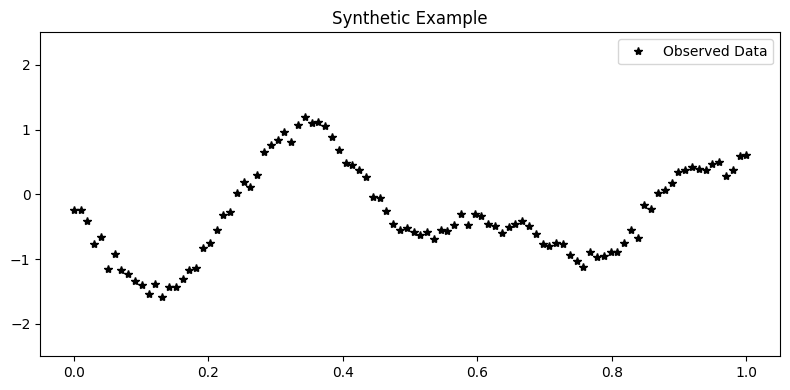

In [23]:
np.random.seed(42)

mean_func = ConstantMean(constant=0.0)
rbf_kernel = RBFKernel(lengthscale=0.1, variance=1.0)

# All 1000 points
x_train = np.linspace(0, 1, 100).reshape(-1, 1)
K_train = rbf_kernel(x_train, x_train)
K_train_noise = K_train + 1e-2 * np.eye(len(x_train))
y_train = np.random.multivariate_normal(mean_func(x_train).flatten(), K_train_noise).reshape(-1, 1)

# Plotting
fig, axs = plt.subplots(1, 1, figsize=(8, 4))

# Plot noisy observations and true function
axs.plot(x_train, y_train, 'k*', label='Observed Data')

axs.set_title("Synthetic Example")
axs.set_ylim([-2.5, 2.5])
axs.legend()

plt.tight_layout()
plt.show()

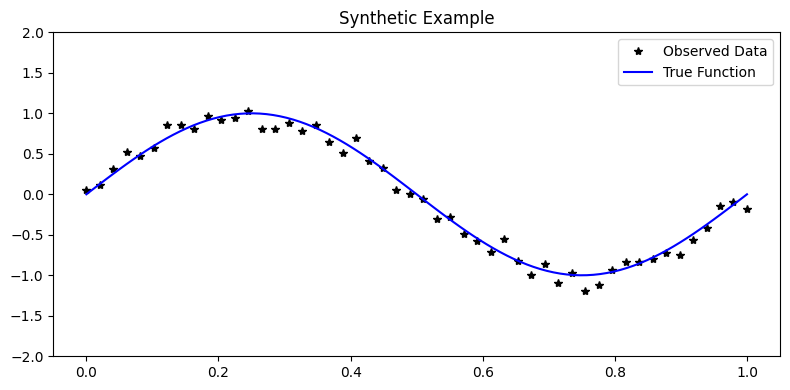

In [ ]:
# Generate synthetic data
np.random.seed(42)
X = np.linspace(0, 1, 50).reshape(-1, 1)


y = np.sin(X * 2 * np.pi).ravel() + 0.1 * np.random.randn(len(X))

# Test points
X_test = np.linspace(0, 1, 100).reshape(-1, 1)
y_true = np.sin(X_test * 2 * np.pi).ravel()  # True function

# Plotting
fig, axs = plt.subplots(1, 1, figsize=(8, 4))

# Plot noisy observations and true function
axs.plot(X, y, 'k*', label='Observed Data')
axs.plot(X_test, y_true, 'b-', label='True Function')

axs.set_title("Synthetic Example")
axs.set_ylim([-2, 2])
axs.legend()

plt.tight_layout()
plt.show()

#### GP

In [ ]:
# Initialize and train GP
mean = ConstantMean(constant=0.0)
kernel = RBFKernel(lengthscale=0.4, variance=1.0)
gp = GaussianProcessRegressor(mean, kernel, noise=0.08)
gp.fit(X, y)
# gp.optimize_hyperparameters(initial_params=[0.5, 1.0, 0.1],
                                          # learning_rate=0.1,
                                          # max_iters=100,
                                          # tol=1e-4)

# Predict
mu, cov = gp.predict(X_test)
std = np.sqrt(np.diag(cov))

# Plot
plt.figure(figsize=(10, 5))
plt.plot(X, y, 'k*', label='Train data')
plt.plot(X_test, mu.ravel(), 'b', label='Predictive mean')
plt.fill_between(X_test.ravel(), mu.ravel() - 2 * std, mu.ravel() + 2 * std, alpha=0.3, color='blue')
plt.title("Gaussian Process Regression")
plt.ylim(-2, 2)
plt.legend()
plt.show()


ValueError: operands could not be broadcast together with shapes (50,1) (100,1) 

#### GPyTorch

In [ ]:
!pip install gpytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 277.7/277.7 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.3/176.3 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.4/55.4 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 86.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 70.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 46.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Learned hyperparameters:
Lengthscale: 0.2885
Outputscale (kernel variance): 1.0348
Noise (likelihood variance): 0.0083


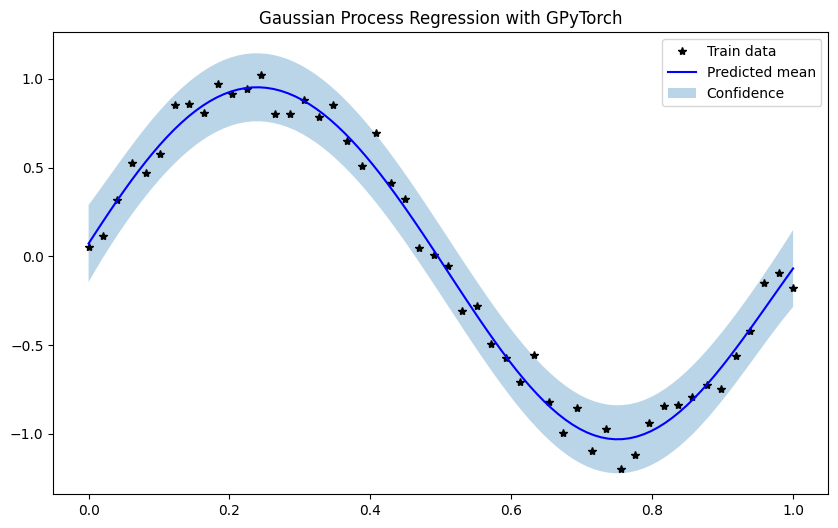

In [ ]:
import torch
import gpytorch
import numpy as np
import matplotlib.pyplot as plt

# Convert to torch tensors
train_x = torch.tensor(X, dtype=torch.float32).squeeze()
train_y = torch.tensor(y, dtype=torch.float32)

test_x = torch.tensor(X_test, dtype=torch.float32).squeeze()

# Define GP model
class ExactGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel()
        )

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

# Instantiate likelihood and model
likelihood = gpytorch.likelihoods.GaussianLikelihood()
model = ExactGPModel(train_x, train_y, likelihood)

# Training mode
model.train()
likelihood.train()

# Optimizer and loss
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

# Training loop
for i in range(100):
    optimizer.zero_grad()
    output = model(train_x)
    loss = -mll(output, train_y)
    loss.backward()
    optimizer.step()

# Evaluation mode
model.eval()
likelihood.eval()

# Predictions
with torch.no_grad(), gpytorch.settings.fast_pred_var():
    preds = likelihood(model(test_x))
    mean = preds.mean
    lower, upper = preds.confidence_region()

print("Learned hyperparameters:")
print(f"Lengthscale: {model.covar_module.base_kernel.lengthscale.item():.4f}")
print(f"Outputscale (kernel variance): {model.covar_module.outputscale.item():.4f}")
print(f"Noise (likelihood variance): {model.likelihood.noise.item():.4f}")

# Plot
plt.figure(figsize=(10, 6))
plt.plot(train_x.numpy(), train_y.numpy(), 'k*', label='Train data')
plt.plot(test_x.numpy(), mean.numpy(), 'b', label='Predicted mean')
plt.fill_between(test_x.numpy(), lower.numpy(), upper.numpy(), alpha=0.3, label='Confidence')
plt.legend()
plt.title('Gaussian Process Regression with GPyTorch')
plt.show()


#### RCGP

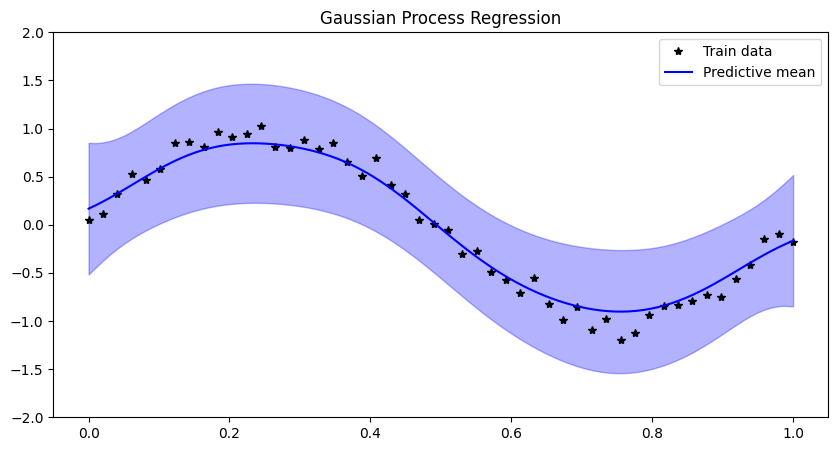

In [ ]:
# Initialize and train GP
mean = ConstantMean(constant=0.0)
kernel = RBFKernel(lengthscale=0.1, variance=1.5)
weight_function = InverseMultiquadraticKernel(0.05, 1.0)
rcgp = RCGPRegressor(mean, kernel, weight_function, noise=0.1)
rcgp.fit(X, y)
# gp.optimize_hyperparameters(initial_params=[0.5, 1.0, 0.1],
#                                           learning_rate=0.01,
#                                           max_iters=100,
#                                           tol=1e-4)

# Predict
mu, cov = rcgp.predict(X_test)
std = np.sqrt(np.diag(cov))

# Plot
plt.figure(figsize=(10, 5))
plt.plot(X, y, 'k*', label='Train data')
plt.plot(X_test, mu.ravel(), 'b', label='Predictive mean')
plt.fill_between(X_test.ravel(), mu.ravel() - std, mu.ravel() + std, alpha=0.3, color='blue')
plt.title("Gaussian Process Regression")
plt.ylim(-2, 2)
plt.legend()
plt.show()

### Sine with missing observations

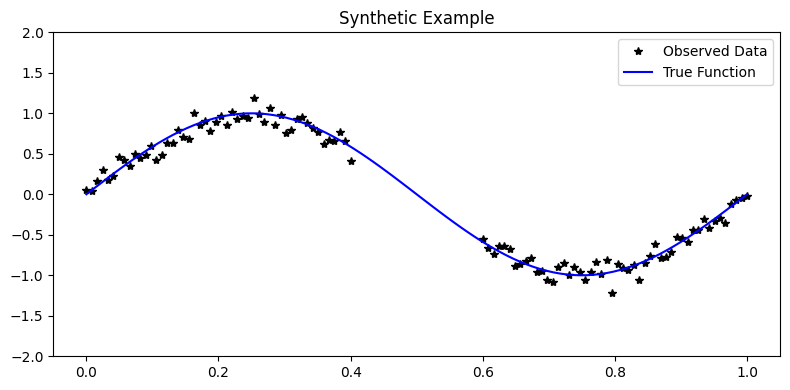

In [ ]:
# Generate synthetic data
np.random.seed(42)
X = np.concatenate([np.linspace(0, 0.4, 50), np.linspace(0.6, 1, 50)]).reshape(-1,1)
y = np.sin(X * 2 * np.pi).ravel() + 0.1 * np.random.randn(len(X))

# Test points
X_test = np.linspace(0, 1, 100).reshape(-1, 1)
y_true = np.sin(X_test * 2 * np.pi).ravel()  # True function

# Plotting
fig, axs = plt.subplots(1, 1, figsize=(8, 4))

# Plot noisy observations and true function
axs.plot(X, y, 'k*', label='Observed Data')
axs.plot(X_test, y_true, 'b-', label='True Function')

axs.set_title("Synthetic Example")
axs.set_ylim([-2, 2])
axs.legend()

plt.tight_layout()
plt.show()

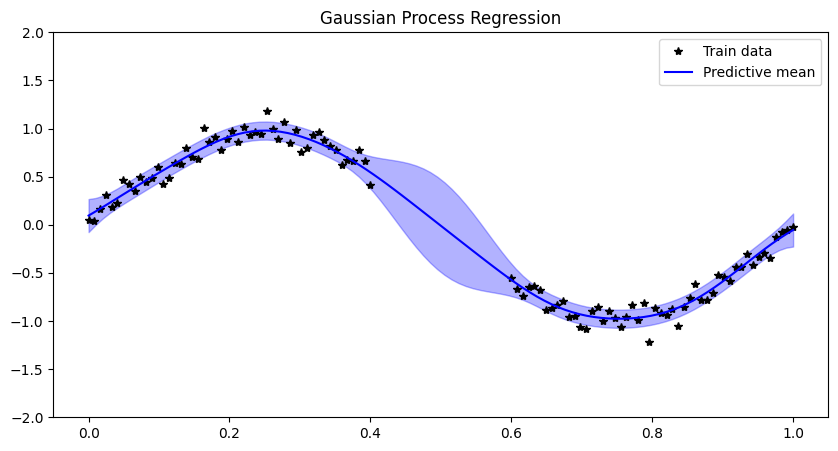

In [ ]:
# Initialize and train GP
mean = ConstantMean(constant=0.0)
kernel = RBFKernel(lengthscale=0.1, variance=1.0)
gp = GaussianProcessRegressor(mean, kernel, noise=0.1)
gp.fit(X, y)
# gp.optimize_hyperparameters(initial_params=[0.5, 1.0, 0.1],
#                                           learning_rate=0.01,
#                                           max_iters=100,
#                                           tol=1e-4)

# Predict
mu, cov = gp.predict(X_test)
std = np.sqrt(np.diag(cov))

# Plot
plt.figure(figsize=(10, 5))
plt.plot(X, y, 'k*', label='Train data')
plt.plot(X_test, mu.ravel(), 'b', label='Predictive mean')
plt.fill_between(X_test.ravel(), mu.ravel() - std, mu.ravel() + std, alpha=0.3, color='blue')
plt.title("Gaussian Process Regression")
plt.ylim(-2, 2)
plt.legend()
plt.show()

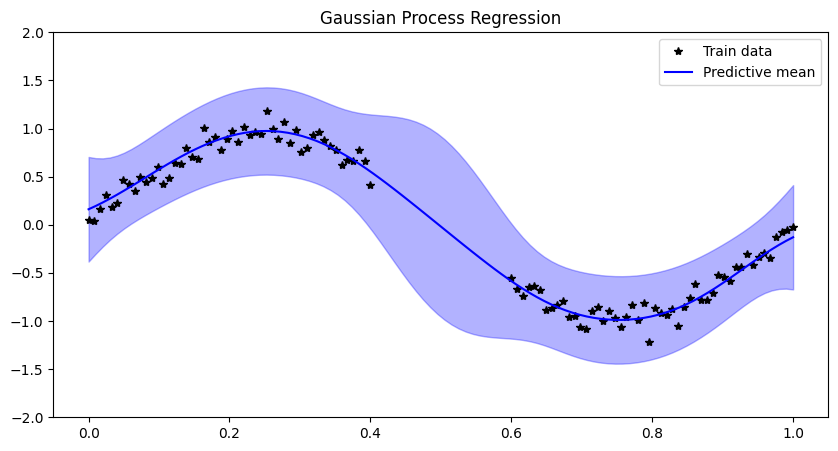

In [ ]:
# Initialize and train GP
mean = ConstantMean(constant=0.0)
kernel = RBFKernel(lengthscale=0.1, variance=1.5)
weight_function = InverseMultiquadraticKernel(0.05, 1.0)
rcgp = RCGPRegressor(mean, kernel, weight_function, noise=0.1)
rcgp.fit(X, y)
# gp.optimize_hyperparameters(initial_params=[0.5, 1.0, 0.1],
#                                           learning_rate=0.01,
#                                           max_iters=100,
#                                           tol=1e-4)

# Predict
mu, cov = rcgp.predict(X_test)
std = np.sqrt(np.diag(cov))

# Plot
plt.figure(figsize=(10, 5))
plt.plot(X, y, 'k*', label='Train data')
plt.plot(X_test, mu.ravel(), 'b', label='Predictive mean')
plt.fill_between(X_test.ravel(), mu.ravel() - std, mu.ravel() + std, alpha=0.3, color='blue')
plt.title("Gaussian Process Regression")
plt.ylim(-2, 2)
plt.legend()
plt.show()

### Sine with outliers

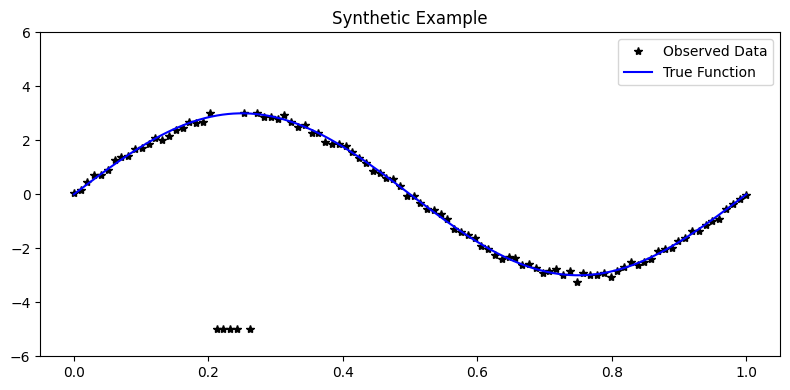

In [ ]:
# Generate synthetic data
np.random.seed(42)
X = np.linspace(0, 1, 100).reshape(-1, 1)
y = 3 * np.sin(X * 2 * np.pi).ravel() + 0.1 * np.random.randn(len(X))

indices_025 = np.where((X >= 0.20) & (X <= 0.27))[0]
# indices_075 = np.where((X >= 0.70) & (X <= 0.77))[0]

# Randomly choose 5 from each for a total of 10 outliers
outlier_indices_025 = np.random.choice(indices_025, 5, replace=False)
# outlier_indices_075 = np.random.choice(indices_075, 5, replace=False)

# Replace values with synthetic outliers
y[outlier_indices_025] = -5
# y[outlier_indices_075] = 3

# Test points
X_test = np.linspace(0, 1, 1000).reshape(-1, 1)
y_true = 3 * np.sin(X_test * 2 * np.pi).ravel()  # True function

# Plotting
fig, axs = plt.subplots(1, 1, figsize=(8, 4))

# Plot noisy observations and true function
axs.plot(X, y, 'k*', label='Observed Data')
axs.plot(X_test, y_true, 'b-', label='True Function')

axs.set_title("Synthetic Example")
axs.set_ylim([-6, 6])
axs.legend()

plt.tight_layout()
plt.show()

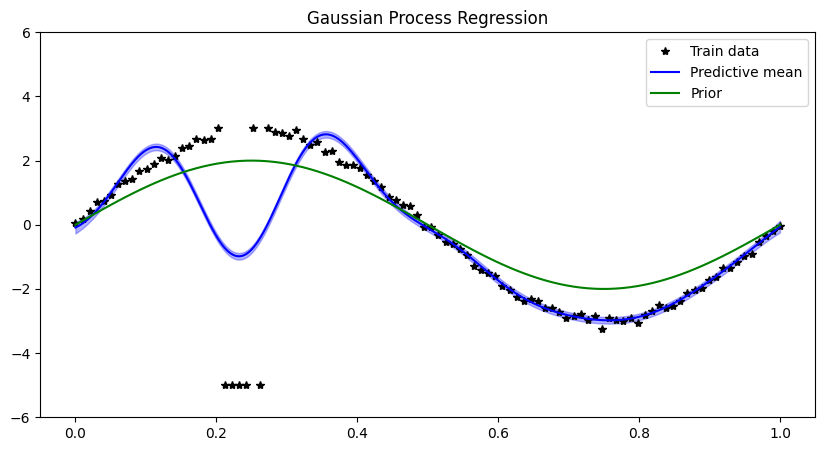

In [ ]:
# Initialize and train GP
mean = SineMean(2, 2*np.pi, 0)
kernel = RBFKernel(lengthscale=0.1, variance=1.0)
gp = GaussianProcessRegressor(mean, kernel, noise=0.1)
gp.fit(X, y)
# gp.optimize_hyperparameters(initial_params=[0.5, 1.0, 0.1],
#                                           learning_rate=0.01,
#                                           max_iters=100,
#                                           tol=1e-4)

# Predict
mu, cov = gp.predict(X_test)
std = np.sqrt(np.diag(cov))

# Plot
plt.figure(figsize=(10, 5))
plt.plot(X, y, 'k*', label='Train data')
plt.plot(X_test, mu.ravel(), 'b', label='Predictive mean')
plt.plot(X, mean(X).ravel(), 'g', label='Prior')
plt.fill_between(X_test.ravel(), mu.ravel() - std, mu.ravel() + std, alpha=0.3, color='blue')
plt.title("Gaussian Process Regression")
plt.ylim(-6, 6)
plt.legend()
plt.show()

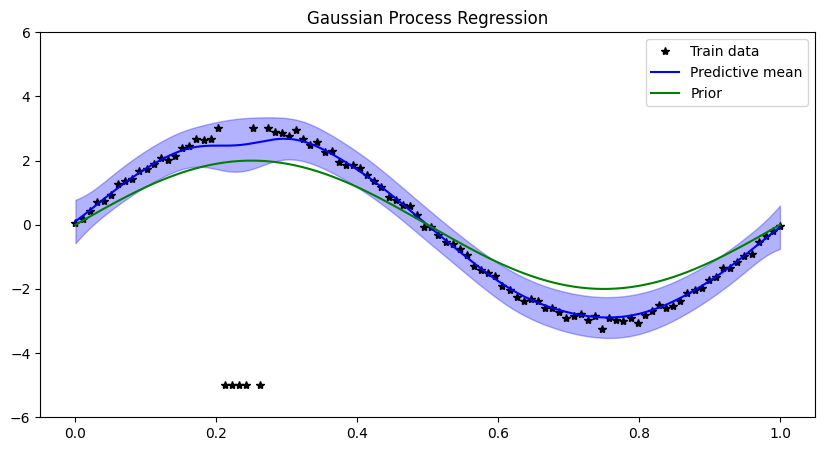

In [ ]:
# Initialize and train GP
mean = SineMean(2, 2*np.pi, 0)
kernel = RBFKernel(lengthscale=0.05, variance=1.5)
weight_function = InverseMultiquadraticKernel(0.05, 1)
rcgp = RCGPRegressor(mean, kernel, weight_function, noise=0.1)
rcgp.fit(X, y)

# Predict
mu, cov = rcgp.predict(X_test)
std = np.sqrt(np.diag(cov))

# Plot
plt.figure(figsize=(10, 5))
plt.plot(X, y, 'k*', label='Train data')
plt.plot(X_test, mu.ravel(), 'b', label='Predictive mean')
plt.plot(X, mean(X).ravel(), 'g', label='Prior')
plt.fill_between(X_test.ravel(), mu.ravel() - std, mu.ravel() + std, alpha=0.3, color='blue')
plt.title("Gaussian Process Regression")
plt.ylim(-6, 6)
plt.legend()
plt.show()

## Experiments Multi-output GP

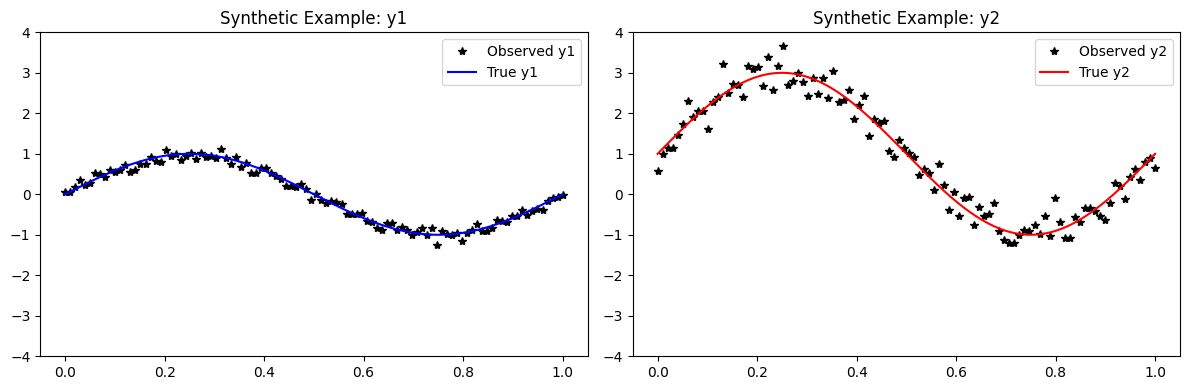

In [6]:
# Generate synthetic data
np.random.seed(42)
X = np.linspace(0, 1, 100).reshape(-1, 1)

y1 = np.sin(X * 2 * np.pi).ravel() + 0.1 * np.random.randn(len(X))
y2 = 1 + 2 * np.sin(X * 2 * np.pi).ravel() + 0.3 * np.random.randn(len(X))
Y = np.column_stack([y1, y2])

# Test points
X_test = np.linspace(0, 1, 1000).reshape(-1, 1)
y1_true = np.sin(X_test * 2 * np.pi).ravel()  # True function
y2_true = 1 + 2 * np.sin(X_test * 2 * np.pi).ravel()

# Plotting
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# First subplot: y1
axs[0].plot(X, y1, 'k*', label='Observed y1')
axs[0].plot(X_test, y1_true, 'b-', label='True y1')
axs[0].set_title("Synthetic Example: y1")
axs[0].set_ylim([-4, 4])
axs[0].legend()

# Second subplot: y2
axs[1].plot(X, y2, 'k*', label='Observed y2')
axs[1].plot(X_test, y2_true, 'r-', label='True y2')
axs[1].set_title("Synthetic Example: y2")
axs[1].set_ylim([-4, 4])
axs[1].legend()

plt.tight_layout()
plt.show()

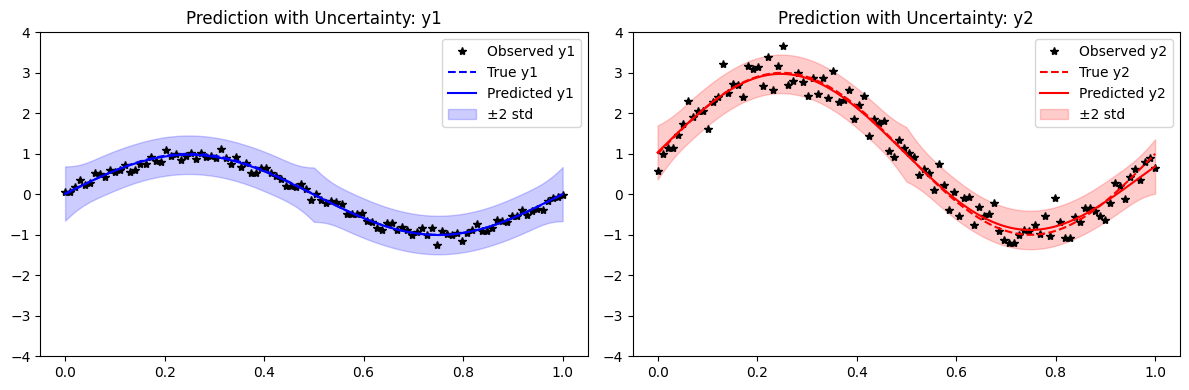

In [9]:
cov12 = 0.8
B = np.array([[1.0, cov12],
              [cov12, 1.0]])

# Initialize and train GP
mean = ConstantMean(constant=0.0)
kernel = RBFKernel(lengthscale=0.2885, variance=1.0)
mogp = MultiOutputGP(mean, kernel, B, noise_variance=0.08)
mogp.fit(X, Y)
# gp.optimize_hyperparameters(initial_params=[0.5, 1.0, 0.1],
                                          # learning_rate=0.1,
                                          # max_iters=100,
                                          # tol=1e-4)

# Predict
mu, cov = mogp.predict(X_test)
std = np.sqrt(np.diag(cov)).reshape(-1,2)

# Unpack predictions
mu1, mu2 = mu[:, 0], mu[:, 1]
std1, std2 = np.sqrt(std[:, 0]), np.sqrt(std[:, 1])

# Plotting
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# First subplot: y1
axs[0].plot(X, y1, 'k*', label='Observed y1')
axs[0].plot(X_test, y1_true, 'b--', label='True y1')
axs[0].plot(X_test, mu1, 'b-', label='Predicted y1')
axs[0].fill_between(X_test.ravel(), mu1 - 2*std1, mu1 + 2*std1, color='b', alpha=0.2, label='±2 std')
axs[0].set_title("Prediction with Uncertainty: y1")
axs[0].set_ylim([-4, 4])
axs[0].legend()

# Second subplot: y2
axs[1].plot(X, y2, 'k*', label='Observed y2')
axs[1].plot(X_test, y2_true, 'r--', label='True y2')
axs[1].plot(X_test, mu2, 'r-', label='Predicted y2')
axs[1].fill_between(X_test.ravel(), mu2 - 2*std2, mu2 + 2*std2, color='r', alpha=0.2, label='±2 std')
axs[1].set_title("Prediction with Uncertainty: y2")
axs[1].set_ylim([-4, 4])
axs[1].legend()

plt.tight_layout()
plt.show()

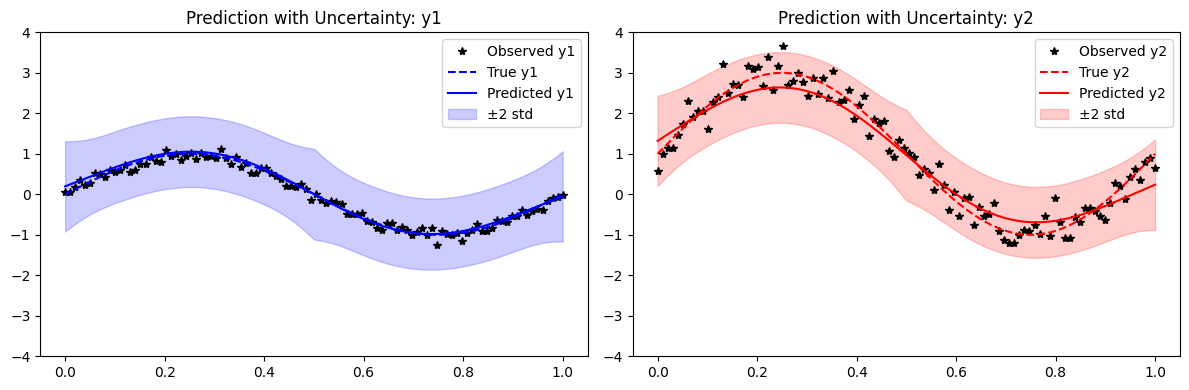

In [12]:
cov12 = 0.8
B = np.array([[1.0, cov12],
              [cov12, 1.0]])

# Initialize and train GP
mean = ConstantMean(constant=0.0)
kernel = RBFKernel(lengthscale=0.2885, variance=1.0)
weight_function = InverseMultiquadraticKernel(0.05, 10)
rcmogp = RCMOGP(mean, kernel, B, weight_function, noise_variance=0.08)
rcmogp.fit(X, Y)
# gp.optimize_hyperparameters(initial_params=[0.5, 1.0, 0.1],
                                          # learning_rate=0.1,
                                          # max_iters=100,
                                          # tol=1e-4)

# Predict
mu, cov = rcmogp.predict(X_test)
std = np.sqrt(np.diag(cov)).reshape(-1,2)

# Unpack predictions
mu1, mu2 = mu[:, 0], mu[:, 1]
std1, std2 = np.sqrt(std[:, 0]), np.sqrt(std[:, 1])

# Plotting
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# First subplot: y1
axs[0].plot(X, y1, 'k*', label='Observed y1')
axs[0].plot(X_test, y1_true, 'b--', label='True y1')
axs[0].plot(X_test, mu1, 'b-', label='Predicted y1')
axs[0].fill_between(X_test.ravel(), mu1 - 2*std1, mu1 + 2*std1, color='b', alpha=0.2, label='±2 std')
axs[0].set_title("Prediction with Uncertainty: y1")
axs[0].set_ylim([-4, 4])
axs[0].legend()

# Second subplot: y2
axs[1].plot(X, y2, 'k*', label='Observed y2')
axs[1].plot(X_test, y2_true, 'r--', label='True y2')
axs[1].plot(X_test, mu2, 'r-', label='Predicted y2')
axs[1].fill_between(X_test.ravel(), mu2 - 2*std2, mu2 + 2*std2, color='r', alpha=0.2, label='±2 std')
axs[1].set_title("Prediction with Uncertainty: y2")
axs[1].set_ylim([-4, 4])
axs[1].legend()

plt.tight_layout()
plt.show()

#### Sine with outliers

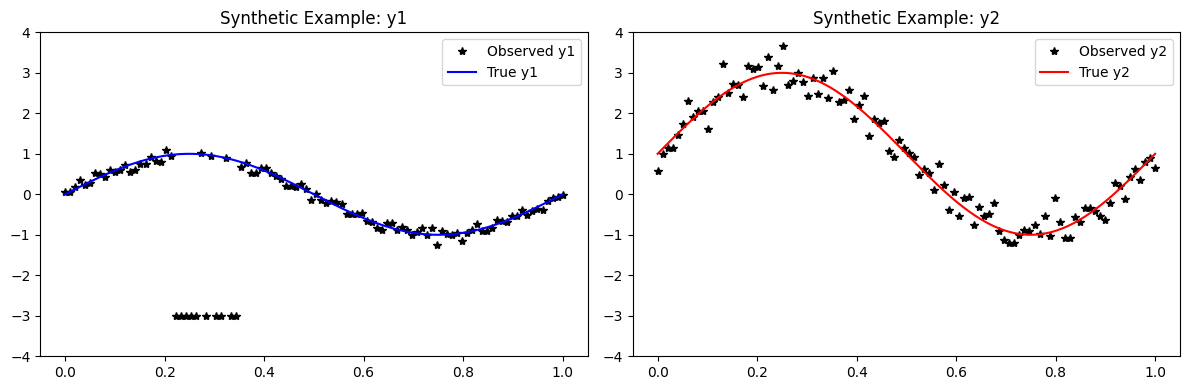

In [24]:
# Generate synthetic data
np.random.seed(42)
X = np.linspace(0, 1, 100).reshape(-1, 1)

y1 = np.sin(X * 2 * np.pi).ravel() + 0.1 * np.random.randn(len(X))
y2 = 1 + 2 * np.sin(X * 2 * np.pi).ravel() + 0.3 * np.random.randn(len(X))

indices_025 = np.where((X >= 0.20) & (X <= 0.35))[0]
# indices_075 = np.where((X >= 0.70) & (X <= 0.77))[0]

# Randomly choose 5 from each for a total of 10 outliers
outlier_indices_025 = np.random.choice(indices_025, 10, replace=False)
# outlier_indices_075 = np.random.choice(indices_075, 5, replace=False)

# Replace values with synthetic outliers
y1[outlier_indices_025] = -3

Y = np.column_stack([y1, y2])

# Test points
X_test = np.linspace(0, 1, 1000).reshape(-1, 1)
y1_true = np.sin(X_test * 2 * np.pi).ravel()  # True function
y2_true = 1 + 2 * np.sin(X_test * 2 * np.pi).ravel()

# Plotting
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# First subplot: y1
axs[0].plot(X, y1, 'k*', label='Observed y1')
axs[0].plot(X_test, y1_true, 'b-', label='True y1')
axs[0].set_title("Synthetic Example: y1")
axs[0].set_ylim([-4, 4])
axs[0].legend()

# Second subplot: y2
axs[1].plot(X, y2, 'k*', label='Observed y2')
axs[1].plot(X_test, y2_true, 'r-', label='True y2')
axs[1].set_title("Synthetic Example: y2")
axs[1].set_ylim([-4, 4])
axs[1].legend()

plt.tight_layout()
plt.show()

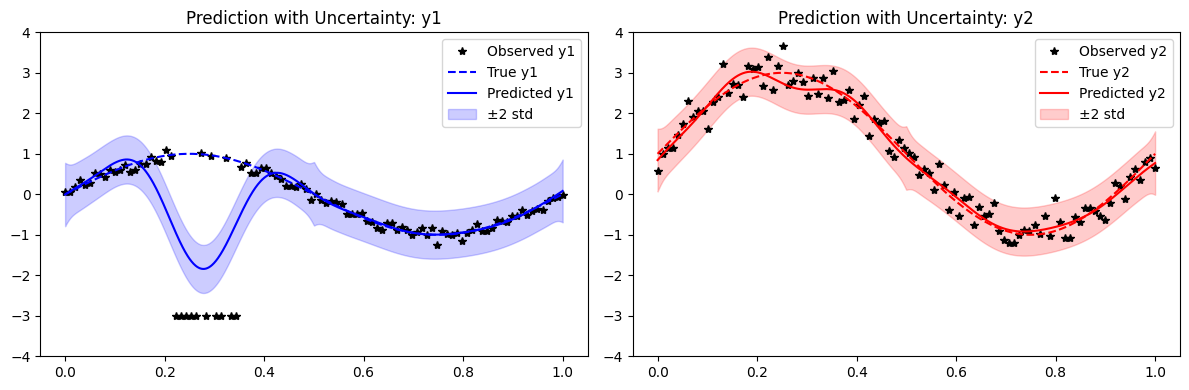

In [25]:
cov12 = 0.9
B = np.array([[1.0, cov12],
              [cov12, 1.0]])

# Initialize and train GP
mean = SineMean(2, 2*np.pi, 0)
# mean = ConstantMean(constant=0.0)
kernel = RBFKernel(lengthscale=0.1, variance=1.0)
mogp = MultiOutputGP(mean, kernel, B, noise_variance=0.08)
mogp.fit(X, Y)
# gp.optimize_hyperparameters(initial_params=[0.5, 1.0, 0.1],
                                          # learning_rate=0.1,
                                          # max_iters=100,
                                          # tol=1e-4)

# Compute prior mean before training
prior_mu1, prior_mu2 = mean(X_test), mean(X_test)

# Predict
mu, cov = mogp.predict(X_test)
std = np.sqrt(np.diag(cov)).reshape(-1,2)

# Unpack predictions
mu1, mu2 = mu[:, 0], mu[:, 1]
std1, std2 = np.sqrt(std[:, 0]), np.sqrt(std[:, 1])

# Plotting
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# First subplot: y1
axs[0].plot(X, y1, 'k*', label='Observed y1')
axs[0].plot(X_test, y1_true, 'b--', label='True y1')
axs[0].plot(X_test, mu1, 'b-', label='Predicted y1')
axs[0].fill_between(X_test.ravel(), mu1 - 2*std1, mu1 + 2*std1, color='b', alpha=0.2, label='±2 std')
axs[0].set_title("Prediction with Uncertainty: y1")
axs[0].set_ylim([-4, 4])
axs[0].legend()

# Second subplot: y2
axs[1].plot(X, y2, 'k*', label='Observed y2')
axs[1].plot(X_test, y2_true, 'r--', label='True y2')
axs[1].plot(X_test, mu2, 'r-', label='Predicted y2')
axs[1].fill_between(X_test.ravel(), mu2 - 2*std2, mu2 + 2*std2, color='r', alpha=0.2, label='±2 std')
axs[1].set_title("Prediction with Uncertainty: y2")
axs[1].set_ylim([-4, 4])
axs[1].legend()

plt.tight_layout()
plt.show()

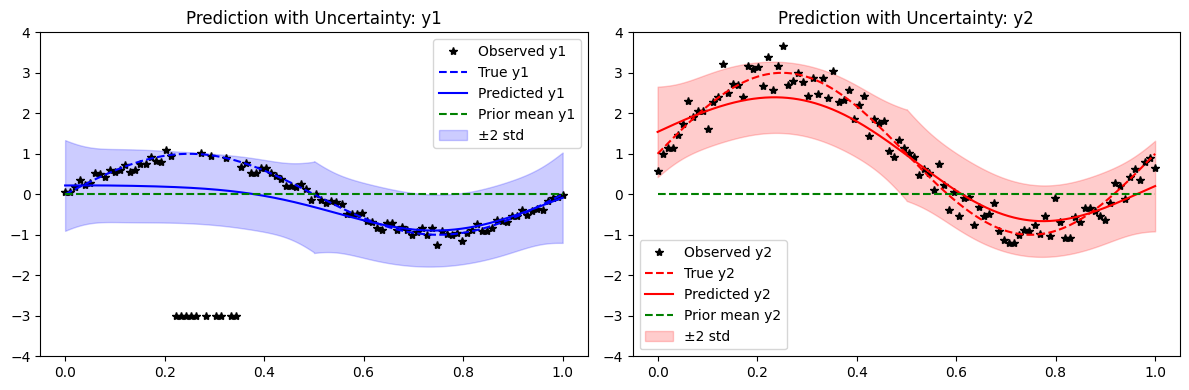

In [28]:
cov12 = 0.8
B = np.array([[1.0, cov12],
              [cov12, 1.0]])

# Initialize and train GP
# mean = SineMean(2, 2*np.pi, 0)
mean = ConstantMean(constant=0.0)
kernel = RBFKernel(lengthscale=0.2885, variance=1.0)
weight_function = InverseMultiquadraticKernel(0.05, 5)
rcmogp = RCMOGP(mean, kernel, B, weight_function, noise_variance=0.08)
rcmogp.fit(X, Y)
# gp.optimize_hyperparameters(initial_params=[0.5, 1.0, 0.1],
                                          # learning_rate=0.1,
                                          # max_iters=100,
                                          # tol=1e-4)


# Compute prior mean before training
prior_mu1, prior_mu2 = mean(X_test), mean(X_test)

# Predict
mu, cov = rcmogp.predict(X_test)
std = np.sqrt(np.diag(cov)).reshape(-1,2)

# Unpack predictions
mu1, mu2 = mu[:, 0], mu[:, 1]
std1, std2 = np.sqrt(std[:, 0]), np.sqrt(std[:, 1])

# Plotting
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# Plot y1
axs[0].plot(X, y1, 'k*', label='Observed y1')
axs[0].plot(X_test, y1_true, 'b--', label='True y1')
axs[0].plot(X_test, mu1, 'b-', label='Predicted y1')
axs[0].plot(X_test, prior_mu1, 'g--', label='Prior mean y1')  # Prior
axs[0].fill_between(X_test.ravel(), mu1 - 2*std1, mu1 + 2*std1, color='b', alpha=0.2, label='±2 std')
axs[0].set_title("Prediction with Uncertainty: y1")
axs[0].set_ylim([-4, 4])
axs[0].legend()

# Plot y2
axs[1].plot(X, y2, 'k*', label='Observed y2')
axs[1].plot(X_test, y2_true, 'r--', label='True y2')
axs[1].plot(X_test, mu2, 'r-', label='Predicted y2')
axs[1].plot(X_test, prior_mu2, 'g--', label='Prior mean y2')  # Prior
axs[1].fill_between(X_test.ravel(), mu2 - 2*std2, mu2 + 2*std2, color='r', alpha=0.2, label='±2 std')
axs[1].set_title("Prediction with Uncertainty: y2")
axs[1].set_ylim([-4, 4])
axs[1].legend()

plt.tight_layout()
plt.show()